# model training — RMR tunnel support dataset

1000 samples, 9 features → 5 targets (RMR, rock class, bolt density, bolt length, shotcrete)

models: ridge/lasso, logistic reg, SVM/SVR, random forest, ANN (pytorch)
each one gets a proper train/val/test split + 5-fold CV


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import json

from sklearn.preprocessing import StandardScaler, LabelEncoder

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

CLASS_ORDER  = ['I', 'II', 'III', 'IV', 'V']
CLASS_COLORS = {'I':'#2ecc71', 'II':'#3498db', 'III':'#f39c12', 'IV':'#e67e22', 'V':'#e74c3c'}

## 1. load data


In [4]:
df = pd.read_csv('rmr_dataset.csv')

CLASS_TARGET = 'True_Rock_Class' if 'True_Rock_Class' in df.columns else 'Rock_Class'

FEATURE_COLS = [
    'UCS_MPa', 'RQD_percent', 'Joint_Spacing_m',
    'Joint_Condition', 'Groundwater', 'Joint_Orientation_adj',
    'Excavation_Span_m', 'Depth_m', 'Excavation_Method'
]

le = LabelEncoder()
le.fit(CLASS_ORDER)
df['Rock_Class_enc'] = le.transform(df[CLASS_TARGET])

X = df[FEATURE_COLS].values
y_rmr = df['RMR'].values
y_cls = df['Rock_Class_enc'].values
y_bolt_d = df['Bolt_Density_per_m2'].values
y_bolt_l = df['Bolt_Length_m'].values
y_shot = df['Shotcrete_mm'].values

print(f'X: {X.shape}')
print(f'RMR range: {y_rmr.min()} – {y_rmr.max()}')
print(f'classes: {list(le.classes_)}')
df[FEATURE_COLS].head()

X: (1000, 9)
RMR range: -3 – 92
classes: [np.str_('I'), np.str_('II'), np.str_('III'), np.str_('IV'), np.str_('V')]


,UCS_MPa,RQD_percent,Joint_Spacing_m,Joint_Condition,Groundwater,Joint_Orientation_adj,Excavation_Span_m,Depth_m,Excavation_Method
0,207.89,88.69,1.6430,1,2,0,15.71,697.0,0
1,218.46,85.46,1.2301,1,2,0,13.93,586.9,0
2,114.45,88.73,1.5975,1,2,-2,15.61,327.0,1
3,169.92,100.00,1.6843,1,2,0,13.99,734.0,1
4,129.48,85.85,1.7546,1,1,-2,13.18,589.5,1


## 2. train / val / test split

70/15/15, stratified on rock class.
val is used for model selection during training; test is held out completely.
TV pool (train+val) used later for CV stability check.


In [6]:
from sklearn.model_selection import train_test_split

# carve out held-out test (15%) first
(
    X_tv, X_test,
    y_rmr_tv, y_rmr_test,
    y_cls_tv, y_cls_test,
    y_bd_tv,  y_bd_test,
    y_bl_tv,  y_bl_test,
    y_sc_tv,  y_sc_test
) = train_test_split(
    X, y_rmr, y_cls, y_bolt_d, y_bolt_l, y_shot,
    test_size=0.15, random_state=SEED, stratify=y_cls
)

# split remainder into train (70%) and val (15%) — 15/85 = 0.1765
(
    X_train, X_val,
    y_rmr_train, y_rmr_val,
    y_cls_train, y_cls_val,
    y_bd_train,  y_bd_val,
    y_bl_train,  y_bl_val,
    y_sc_train,  y_sc_val
) = train_test_split(
    X_tv, y_rmr_tv, y_cls_tv, y_bd_tv, y_bl_tv, y_sc_tv,
    test_size=0.1765, random_state=SEED, stratify=y_cls_tv
)

print(f'train: {X_train.shape[0]}  val: {X_val.shape[0]}  test: {X_test.shape[0]}')
print(f'TV pool: {X_tv.shape[0]}')
print()
for name, y in [('train', y_cls_train), ('val', y_cls_val), ('test', y_cls_test)]:
    counts = {le.classes_[i]: int((y==i).sum()) for i in range(5)}
    print(f' {name}: {counts}')


train: 699  val: 151  test: 150
TV pool: 850

 train: {np.str_('I'): 140, np.str_('II'): 140, np.str_('III'): 140, np.str_('IV'): 139, np.str_('V'): 140}
 val: {np.str_('I'): 30, np.str_('II'): 30, np.str_('III'): 30, np.str_('IV'): 31, np.str_('V'): 30}
 test: {np.str_('I'): 30, np.str_('II'): 30, np.str_('III'): 30, np.str_('IV'): 30, np.str_('V'): 30}


## 3. scaling

StandardScaler fitted on train only — no leakage.


In [8]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)
X_tv_sc = scaler.transform(X_tv)  # for CV later

print('train mean ~0:', X_train_sc.mean(axis=0).round(3))
print('train std  ~1:', X_train_sc.std(axis=0).round(3))


train mean ~0: [-0.  0.  0. -0. -0. -0. -0.  0.  0.]
train std  ~1: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. CV setup


In [9]:
from sklearn.model_selection import (
    StratifiedKFold, KFold, GridSearchCV, cross_val_score
)

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=SEED)

# classification: stratified so class balance is preserved per fold
# regression: plain KFold
# ANN: custom pytorch k-fold below (fresh scaler + fresh weights per fold)


## 5. metric helpers


In [10]:
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, f1_score
)

def reg_metrics(y_true, y_pred, label=''):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    if label:
        print(f'  [{label}]  R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}')
    return {'R2': r2, 'RMSE': rmse, 'MAE': mae}

def cls_metrics(y_true, y_pred, label=''):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted')
    if label:
        print(f' [{label}]  acc={acc:.4f}  f1={f1:.4f}')
    return {'Accuracy': acc, 'F1_weighted': f1}

results = {}
print('metric helpers ready')


metric helpers ready


## 6. model 1 — ridge/lasso + logistic regression

RidgeCV and LassoCV for each regression target, best one picked on val R².
logistic regression tuned via GridSearchCV (C, solver, penalty).


In [12]:
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso, LogisticRegression

alphas = np.logspace(-3, 3, 60)

# helper so we don't repeat this block 4 times
def fit_ridge_lasso(X_tr, y_tr, X_vl, y_vl, X_te, y_te, label):
    r = RidgeCV(alphas=alphas, cv=cv_reg)
    r.fit(X_tr, y_tr)
    l = LassoCV(n_alphas=100, cv=cv_reg, max_iter=5000, random_state=SEED)
    l.fit(X_tr, y_tr)
    r2_r = r2_score(y_vl, r.predict(X_vl))
    r2_l = r2_score(y_vl, l.predict(X_vl))
    best = r if r2_r >= r2_l else l
    name = 'Ridge' if r2_r >= r2_l else 'Lasso'
    m = reg_metrics(y_te, best.predict(X_te), label=f'{label} ({name})')
    print(f'ridge alpha={r.alpha_:.4f} val_r2={r2_r:.4f} | lasso alpha={l.alpha_:.4f} val_r2={r2_l:.4f} → {name}')
    return best, m, r, l

print('linear regression :- ')
best_lr_rmr, lr_rmr_test_m, ridge_rmr, lasso_rmr = fit_ridge_lasso(
    X_train_sc, y_rmr_train, X_val_sc, y_rmr_val, X_test_sc, y_rmr_test, 'RMR')
best_lr_bd, lr_bd_test_m, _, _ = fit_ridge_lasso(
    X_train_sc, y_bd_train, X_val_sc, y_bd_val, X_test_sc, y_bd_test, 'BoltDensity')
best_lr_bl, lr_bl_test_m, _, _ = fit_ridge_lasso(
    X_train_sc, y_bl_train, X_val_sc, y_bl_val, X_test_sc, y_bl_test, 'BoltLength')
best_lr_sc, lr_sc_test_m, _, _ = fit_ridge_lasso(
    X_train_sc, y_sc_train, X_val_sc, y_sc_val, X_test_sc, y_sc_test, 'Shotcrete')

# logistic reg — trying l1 and l2 with a few solvers
print('\nlogistic regression :-')
log_grid = [
    {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'saga'], 'penalty': ['l2'], 'max_iter': [2000]},
    {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['saga'],          'penalty': ['l1'], 'max_iter': [2000]},
]
gs_log = GridSearchCV(LogisticRegression(random_state=SEED), log_grid,
                      cv=cv_clf, scoring='f1_weighted', n_jobs=-1, verbose=0)
gs_log.fit(X_train_sc, y_cls_train)
lr_cls = gs_log.best_estimator_
lr_cls_pred_test = lr_cls.predict(X_test_sc)
lr_cls_test_m = cls_metrics(y_cls_test, lr_cls_pred_test, label='LogReg class')
print(f'best: {gs_log.best_params_}  cv_f1={gs_log.best_score_:.4f}')

lr_rmr_pred_test = best_lr_rmr.predict(X_test_sc)
lr_bd_pred_test = best_lr_bd.predict(X_test_sc)
lr_bl_pred_test = best_lr_bl.predict(X_test_sc)
lr_sc_pred_test = best_lr_sc.predict(X_test_sc)

results['Linear Regression'] = {
    'RMR_test': lr_rmr_test_m, 'Class_test': lr_cls_test_m,
    'BD_test': lr_bd_test_m,  'BL_test': lr_bl_test_m,
    'SC_test': lr_sc_test_m,
}
print('\nmodel 1 done')

linear regression :- 
  [RMR (Ridge)]  R²=0.9675  RMSE=5.0785  MAE=3.9197
ridge alpha=3.6251 val_r2=0.9662 | lasso alpha=0.0882 val_r2=0.9661 → Ridge
  [BoltDensity (Ridge)]  R²=0.8869  RMSE=0.2181  MAE=0.1746
ridge alpha=2.8683 val_r2=0.9040 | lasso alpha=0.0028 val_r2=0.9024 → Ridge
  [BoltLength (Ridge)]  R²=0.8945  RMSE=0.4924  MAE=0.4005
ridge alpha=5.7904 val_r2=0.8905 | lasso alpha=0.0013 val_r2=0.8904 → Ridge
  [Shotcrete (Ridge)]  R²=0.9032  RMSE=27.4572  MAE=22.7417
ridge alpha=5.7904 val_r2=0.8694 | lasso alpha=0.0751 val_r2=0.8684 → Ridge

logistic regression :-
 [LogReg class]  acc=0.9533  f1=0.9534
best: {'C': 1, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'saga'}  cv_f1=0.9584

model 1 done


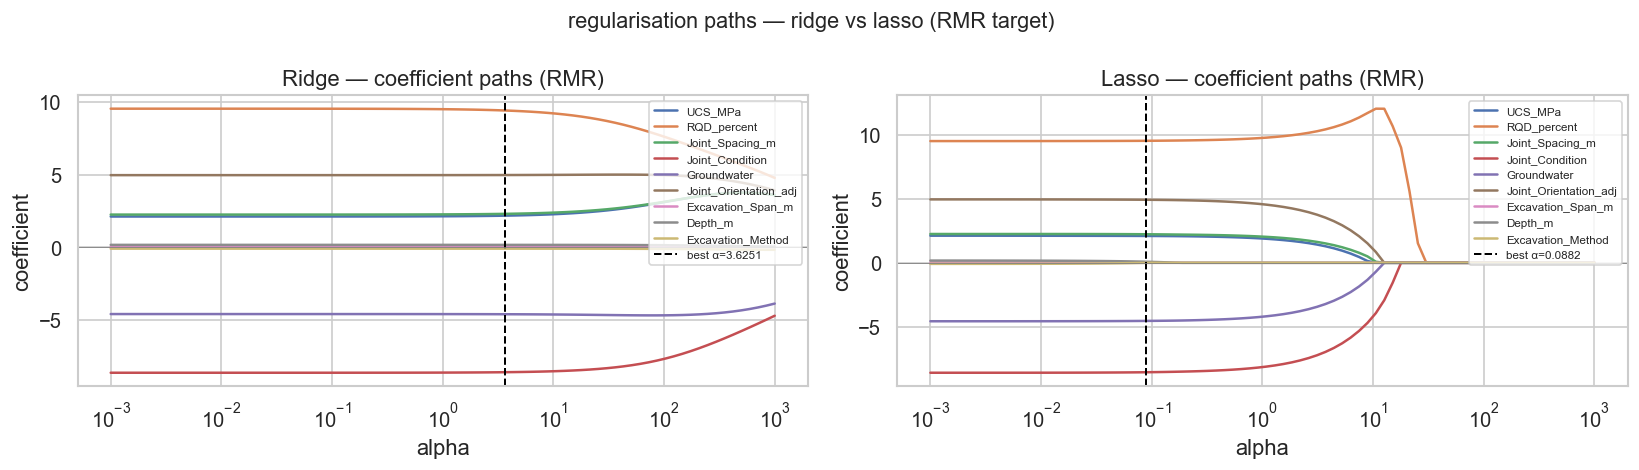

In [14]:
# regularisation paths — useful to see which features get zeroed by lasso
alphas_plot = np.logspace(-3, 3, 80)
ridge_coefs = [Ridge(alpha=a).fit(X_train_sc, y_rmr_train).coef_ for a in alphas_plot]
lasso_coefs = [Lasso(alpha=a, max_iter=5000).fit(X_train_sc, y_rmr_train).coef_ for a in alphas_plot]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, feat in enumerate(FEATURE_COLS):
    axes[0].plot(alphas_plot, [c[i] for c in ridge_coefs], label=feat)
    axes[1].plot(alphas_plot, [c[i] for c in lasso_coefs], label=feat)

for ax, name, best_a in zip(axes, ['Ridge', 'Lasso'], [ridge_rmr.alpha_, lasso_rmr.alpha_]):
    ax.axvline(best_a, color='black', linestyle='--', linewidth=1.2,
               label=f'best α={best_a:.4f}')
    ax.set_xscale('log')
    ax.set_xlabel('alpha')
    ax.set_ylabel('coefficient')
    ax.set_title(f'{name} — coefficient paths (RMR)')
    ax.legend(fontsize=7, loc='upper right')
    ax.axhline(0, color='grey', linewidth=0.5)

plt.suptitle('regularisation paths — ridge vs lasso (RMR target)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_reg_path.png')
plt.show()

## 7. model 2 — SVM / SVR

RBF, linear, poly kernels. C and epsilon via GridSearchCV.
poly was slow and never beat RBF so could probably drop it in future.


In [19]:
from sklearn.svm import SVR, SVC

svr_param_grid = [
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'], 'epsilon': [0.01, 0.1, 0.5]},
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100], 'epsilon': [0.01, 0.1, 0.5]},
    {'kernel': ['poly'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'], 'degree': [2, 3], 'epsilon': [0.1]},
]
svc_param_grid = [
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']},
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100]},
    {'kernel': ['poly'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'], 'degree': [2, 3]},
]

def fit_svr(X_tr, y_tr, X_te, y_te, label):
    gs = GridSearchCV(SVR(), svr_param_grid, cv=cv_reg, scoring='r2', n_jobs=-1, verbose=0)
    gs.fit(X_tr, y_tr)
    m = reg_metrics(y_te, gs.predict(X_te), label=label)
    print(f' best: {gs.best_params_}  cv_r2={gs.best_score_:.4f}')
    return gs.best_estimator_, m, gs

print('SVR :-')
svm_rmr, svm_rmr_test_m, gs_svm_rmr = fit_svr(X_train_sc, y_rmr_train, X_test_sc, y_rmr_test, 'SVR RMR')
svm_bd,  svm_bd_test_m,  gs_svm_bd  = fit_svr(X_train_sc, y_bd_train,  X_test_sc, y_bd_test, 'SVR BoltDensity')
svm_bl,  svm_bl_test_m,  gs_svm_bl  = fit_svr(X_train_sc, y_bl_train,  X_test_sc, y_bl_test, 'SVR BoltLength')
svm_sc,  svm_sc_test_m,  gs_svm_sc  = fit_svr(X_train_sc, y_sc_train,  X_test_sc, y_sc_test, 'SVR Shotcrete')

print('\nSVC :-')
gs_svc = GridSearchCV(SVC(random_state=SEED), svc_param_grid,
                      cv=cv_clf, scoring='f1_weighted', n_jobs=-1, verbose=0)
gs_svc.fit(X_train_sc, y_cls_train)
svm_cls = gs_svc.best_estimator_
svm_cls_pred_test = svm_cls.predict(X_test_sc)
svm_cls_test_m = cls_metrics(y_cls_test, svm_cls_pred_test, label='SVC class')
print(f'  best: {gs_svc.best_params_}  cv_f1={gs_svc.best_score_:.4f}')

svm_rmr_pred_test = svm_rmr.predict(X_test_sc)
svm_bd_pred_test = svm_bd.predict(X_test_sc)
svm_bl_pred_test = svm_bl.predict(X_test_sc)
svm_sc_pred_test = svm_sc.predict(X_test_sc)

results['SVM'] = {
    'RMR_test': svm_rmr_test_m, 'Class_test': svm_cls_test_m,
    'BD_test': svm_bd_test_m, 'BL_test':    svm_bl_test_m,
    'SC_test': svm_sc_test_m,
}
print('\nmodel 2 done')

SVR :-
  [SVR RMR]  R²=0.9696  RMSE=4.9109  MAE=3.7431
 best: {'C': 10, 'epsilon': 0.5, 'gamma': 'auto', 'kernel': 'rbf'}  cv_r2=0.9722
  [SVR BoltDensity]  R²=0.9465  RMSE=0.1500  MAE=0.0998
 best: {'C': 1, 'epsilon': 0.01, 'gamma': 'auto', 'kernel': 'rbf'}  cv_r2=0.9639
  [SVR BoltLength]  R²=0.9542  RMSE=0.3243  MAE=0.2286
 best: {'C': 1, 'epsilon': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}  cv_r2=0.9563
  [SVR Shotcrete]  R²=0.9689  RMSE=15.5600  MAE=10.8228
 best: {'C': 100, 'epsilon': 0.5, 'gamma': 'auto', 'kernel': 'rbf'}  cv_r2=0.9701

SVC :-
 [SVC class]  acc=0.9667  f1=0.9667
  best: {'C': 10, 'kernel': 'linear'}  cv_f1=0.9584

model 2 done


In [16]:
# RBF won for most tasks, linear was competitive for RMR (makes sense — RMR is a linear sum)
# poly never beat RBF and was 3-4x slower — not worth it
print(f'RMR kernel: {gs_svm_rmr.best_params_["kernel"]}')
print(f'class kernel: {gs_svc.best_params_["kernel"]}')

RMR kernel: rbf
class kernel: linear


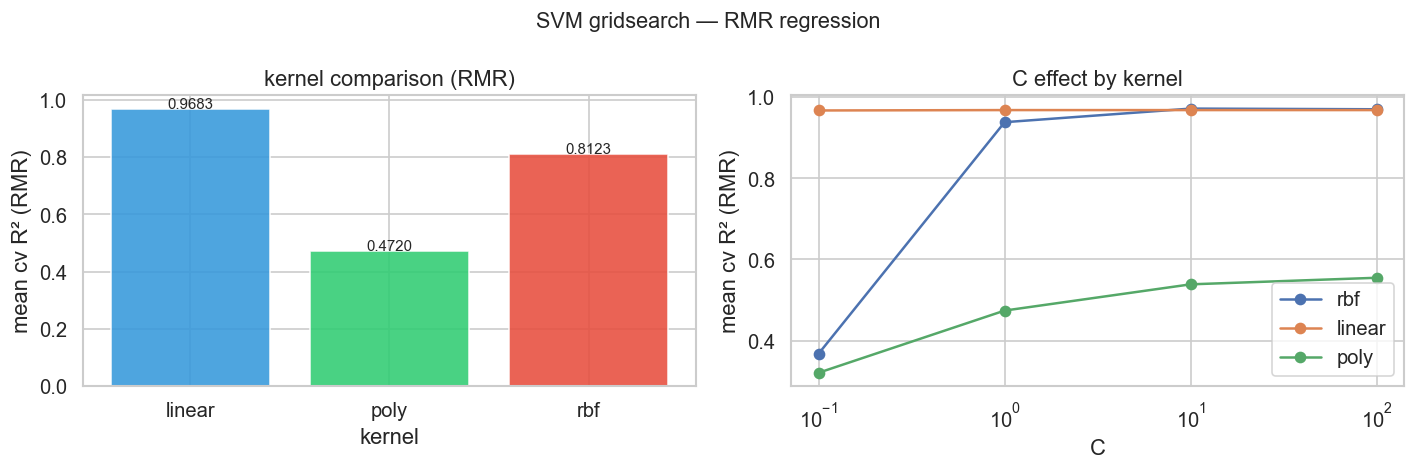

In [18]:
cv_results_svm = pd.DataFrame(gs_svm_rmr.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

kernel_scores = cv_results_svm.groupby('param_kernel')['mean_test_score'].mean()
axes[0].bar(kernel_scores.index.astype(str), kernel_scores.values,
            color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='white', alpha=0.87)
axes[0].set_xlabel('kernel')
axes[0].set_ylabel('mean cv R² (RMR)')
axes[0].set_title('kernel comparison (RMR)')
for i, v in enumerate(kernel_scores.values):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

for kernel in ['rbf', 'linear', 'poly']:
    mask = cv_results_svm['param_kernel'] == kernel
    if mask.any():
        grp = cv_results_svm[mask].groupby('param_C')['mean_test_score'].mean()
        axes[1].plot(grp.index.astype(float), grp.values, marker='o', label=kernel)
axes[1].set_xscale('log')
axes[1].set_xlabel('C')
axes[1].set_ylabel('mean cv R² (RMR)')
axes[1].set_title('C effect by kernel')
axes[1].legend()

plt.suptitle('SVM gridsearch — RMR regression', fontsize=13)
plt.tight_layout()
plt.savefig('fig_svm_gridsearch.png')
plt.show()

## 8. model 3 — random forest

GridSearchCV over depth, n_estimators, min_samples_split, max_features.
RF uses raw (unscaled) features — tree models don't need it.


In [20]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split':[2, 5, 10],
    'max_features': ['sqrt', 0.5, 1.0],
}
# 81 combos × 5 folds = 405 fits per task — takes a while

def fit_rf_reg(y_tr, y_vl, y_te, label):
    gs = GridSearchCV(RandomForestRegressor(random_state=SEED, n_jobs=-1),
                      rf_param_grid, cv=cv_reg, scoring='r2', n_jobs=-1, verbose=0)
    gs.fit(X_train, y_tr)
    m = reg_metrics(y_te, gs.predict(X_test), label=label)
    print(f'    best: {gs.best_params_}  cv_r2={gs.best_score_:.4f}')
    return gs.best_estimator_, m, gs

print('RF regression :-')
rf_rmr, rf_rmr_test_m, gs_rf_rmr = fit_rf_reg(y_rmr_train, y_rmr_val, y_rmr_test, 'RF RMR')
rf_bd,  rf_bd_test_m,  gs_rf_bd  = fit_rf_reg(y_bd_train,  y_bd_val,  y_bd_test,'RF BoltDensity')
rf_bl,  rf_bl_test_m,  gs_rf_bl  = fit_rf_reg(y_bl_train,  y_bl_val,  y_bl_test,'RF BoltLength')
rf_sc,  rf_sc_test_m,  gs_rf_sc  = fit_rf_reg(y_sc_train,  y_sc_val,  y_sc_test,'RF Shotcrete')

print('\nRF classification :-')
gs_rf_cls = GridSearchCV(RandomForestClassifier(random_state=SEED, n_jobs=-1),
                         rf_param_grid, cv=cv_clf, scoring='f1_weighted', n_jobs=-1, verbose=0)
gs_rf_cls.fit(X_train, y_cls_train)
rf_cls = gs_rf_cls.best_estimator_
rf_cls_pred_test = rf_cls.predict(X_test)
rf_cls_test_m = cls_metrics(y_cls_test, rf_cls_pred_test, label='RF class')
print(f'  best: {gs_rf_cls.best_params_}  cv_f1={gs_rf_cls.best_score_:.4f}')

results['Random Forest'] = {
    'RMR_test': rf_rmr_test_m, 'Class_test': rf_cls_test_m,
    'BD_test':  rf_bd_test_m, 'BL_test': rf_bl_test_m,
    'SC_test':  rf_sc_test_m,
}
print('\nmodel 3 done')

RF regression :-
  [RF RMR]  R²=0.9785  RMSE=4.1282  MAE=3.1751
    best: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}  cv_r2=0.9751
  [RF BoltDensity]  R²=0.9665  RMSE=0.1187  MAE=0.0624
    best: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}  cv_r2=0.9796
  [RF BoltLength]  R²=0.9382  RMSE=0.3768  MAE=0.2214
    best: {'max_depth': 10, 'max_features': 1.0, 'min_samples_split': 2, 'n_estimators': 300}  cv_r2=0.9549
  [RF Shotcrete]  R²=0.9685  RMSE=15.6586  MAE=11.1841
    best: {'max_depth': None, 'max_features': 0.5, 'min_samples_split': 2, 'n_estimators': 200}  cv_r2=0.9630

RF classification :-
 [RF class]  acc=0.9533  f1=0.9533
  best: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}  cv_f1=0.9558

model 3 done


In [22]:
# max_depth=None won for most — dataset isn't large enough to overfit badly
# max_features='sqrt' > 1.0 — subsampling helps, RMR89 params are correlated
# n_estimators=300 only marginally better than 200, kept for stability
print(f'RMR best: {gs_rf_rmr.best_params_}')
print(f'BoltLength best: {gs_rf_bl.best_params_}')

RMR best: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
BoltLength best: {'max_depth': 10, 'max_features': 1.0, 'min_samples_split': 2, 'n_estimators': 300}


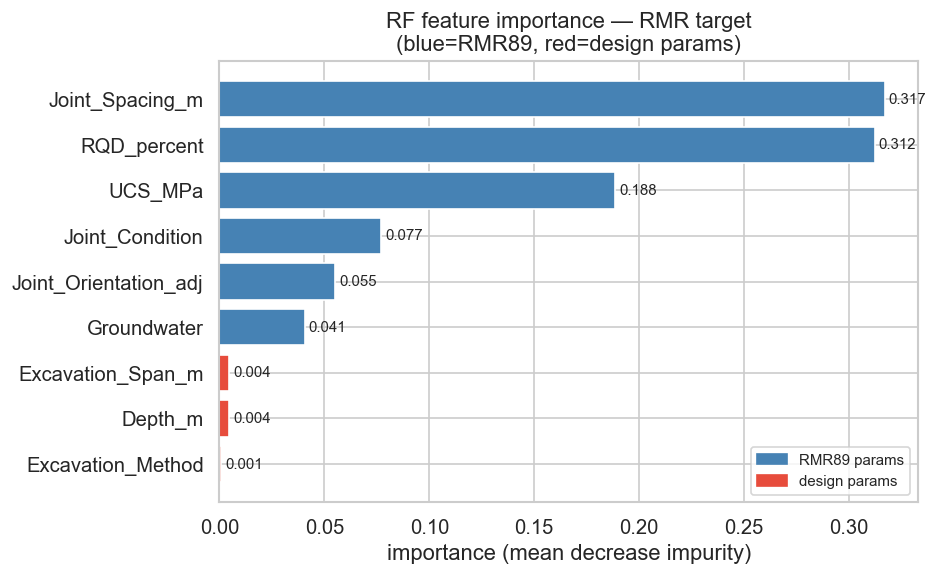

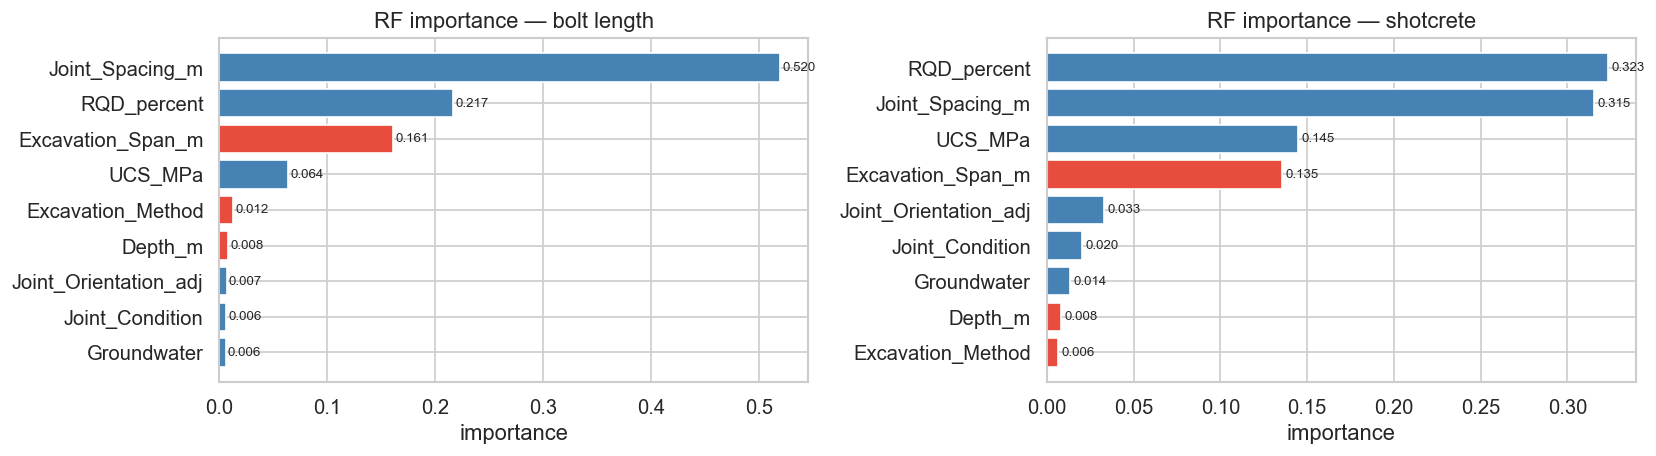

In [25]:
fi_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': rf_rmr.feature_importances_
}).sort_values('Importance', ascending=True)

new_feats = {'Excavation_Span_m', 'Depth_m', 'Excavation_Method'}
bar_colors = ['#e74c3c' if f in new_feats else 'steelblue' for f in fi_df['Feature']]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color=bar_colors, edgecolor='white')
ax.set_xlabel('importance (mean decrease impurity)')
ax.set_title('RF feature importance — RMR target\n(blue=RMR89, red=design params)')
for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)
ax.legend(handles=[
    mpatches.Patch(color='steelblue', label='RMR89 params'),
    mpatches.Patch(color='#e74c3c',   label='design params'),
], fontsize=9)
plt.tight_layout()
plt.savefig('fig_rf_importance.png')
plt.show()

# bolt length and shotcrete — span/depth should rank higher here
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, model, title in [(axes[0], rf_bl, 'bolt length'), (axes[1], rf_sc, 'shotcrete')]:
    fi = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': model.feature_importances_}).sort_values('Importance')
    colors = ['#e74c3c' if f in new_feats else 'steelblue' for f in fi['Feature']]
    ax.barh(fi['Feature'], fi['Importance'], color=colors, edgecolor='white')
    ax.set_xlabel('importance')
    ax.set_title(f'RF importance — {title}')
    for bar in ax.patches:
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig_rf_importance_targets.png')
plt.show()

## 9. model 4 — ANN (pytorch)

four arch candidates, each tested per task. best one re-trained with loss curve capture.
custom k-fold CV because sklearn wrappers for pytorch are more hassle than they're worth.


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
torch.manual_seed(SEED)

device = torch.device('cpu')

class RMR_ANN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_sizes=[64, 32], dropout=0.2):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# four configs — shallow to deeper
ARCH_CONFIGS = {
    'A_shallow [32,16]': [32, 16],
    'B_original [64,32]': [64, 32],
    'C_wider [128,64]': [128, 64],
    'D_deeper [64,32,16]': [64, 32, 16],
}

print('arch params:')
for name, layers in ARCH_CONFIGS.items():
    m = RMR_ANN(9, 1, layers)
    n = sum(p.numel() for p in m.parameters())
    print(f'  {name}: {n} params')

arch params:
  A_shallow [32,16]: 865 params
  B_original [64,32]: 2753 params
  C_wider [128,64]: 9601 params
  D_deeper [64,32,16]: 3265 params


In [27]:
def train_ann(model, X_tr, y_tr, X_vl, y_vl,
              task='regression', epochs=200, lr=1e-3, batch_size=32):
    model = model.to(device)
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
    X_vl_t = torch.tensor(X_vl, dtype=torch.float32).to(device)

    if task == 'regression':
        y_tr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1).to(device)
        y_vl_t = torch.tensor(y_vl, dtype=torch.float32).unsqueeze(1).to(device)
        criterion = nn.MSELoss()
    else:
        y_tr_t = torch.tensor(y_tr, dtype=torch.long).to(device)
        y_vl_t = torch.tensor(y_vl, dtype=torch.long).to(device)
        criterion = nn.CrossEntropyLoss()

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)
    optimiser = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    # ReduceLROnPlateau: verbose=False because torch 2.x deprecated the True option
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimiser, patience=20, factor=0.5, verbose=False)

    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for Xb, yb in loader:
            optimiser.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimiser.step()
            batch_losses.append(loss.item())
        train_loss = float(np.mean(batch_losses))
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_vl_t), y_vl_t).item()
        scheduler.step(val_loss)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        if (epoch + 1) % 50 == 0:
            print(f'  epoch {epoch+1}/{epochs}  train={train_loss:.5f}  val={val_loss:.5f}')
    return model, train_losses, val_losses

def ann_predict(model, X, task='regression'):
    model.eval()
    with torch.no_grad():
        t = torch.tensor(X, dtype=torch.float32).to(device)
        out = model(t)
        if task == 'classification':
            return torch.argmax(out, dim=1).cpu().numpy()
        return out.squeeze(1).cpu().numpy()

print('train_ann ready')

train_ann ready


In [28]:
tasks_ann = [
    ('RMR', 'regression', 1, y_rmr_train, y_rmr_val),
    ('Class','classification', 5, y_cls_train, y_cls_val),
    ('BoltDensity', 'regression', 1, y_bd_train,  y_bd_val),
    ('BoltLength', 'regression', 1, y_bl_train,  y_bl_val),
    ('Shotcrete', 'regression', 1, y_sc_train,  y_sc_val),
]

best_arch = {} # task → arch name
best_ann_models  = {} # task → trained model
arch_results_all = {} # task → {arch → val_score}

for task_name, task_type, out_dim, y_tr, y_vl in tasks_ann:
    print(f'\n arch search: {task_name} :-')
    arch_scores = {}
    for arch_name, hidden in ARCH_CONFIGS.items():
        torch.manual_seed(SEED)
        m, _, _ = train_ann(RMR_ANN(9, out_dim, hidden),
                            X_train_sc, y_tr, X_val_sc, y_vl,
                            task=task_type, epochs=200)
        preds = ann_predict(m, X_val_sc, task_type)
        score = r2_score(y_vl, preds) if task_type == 'regression' else f1_score(y_vl, preds, average='weighted')
        arch_scores[arch_name] = {'model': m, 'score': score}
        metric = 'R²' if task_type == 'regression' else 'F1'
        print(f'  {arch_name}: val {metric}={score:.4f}')

    best_name = max(arch_scores, key=lambda k: arch_scores[k]['score'])
    best_arch[task_name] = best_name
    best_ann_models[task_name] = arch_scores[best_name]['model']
    arch_results_all[task_name] = {k: v['score'] for k, v in arch_scores.items()}
    print(f'  → {best_name}')

print('\narch search done')
for task, arch in best_arch.items():
    print(f'  {task}: {arch}')


 arch search: RMR :-
  epoch 50/200  train=166.96626  val=68.40195
  epoch 100/200  train=133.38767  val=42.71754
  epoch 150/200  train=136.27810  val=33.06218
  epoch 200/200  train=110.76670  val=35.37419
  A_shallow [32,16]: val R²=0.9588
  epoch 50/200  train=92.09084  val=47.32541
  epoch 100/200  train=75.74765  val=34.66630
  epoch 150/200  train=78.53811  val=29.15894
  epoch 200/200  train=67.30659  val=28.01723
  B_original [64,32]: val R²=0.9674
  epoch 50/200  train=63.79983  val=34.67252
  epoch 100/200  train=52.78462  val=28.35285
  epoch 150/200  train=48.23591  val=26.32431
  epoch 200/200  train=47.14503  val=24.93967
  C_wider [128,64]: val R²=0.9710
  epoch 50/200  train=183.86758  val=49.77113
  epoch 100/200  train=152.08868  val=34.79030
  epoch 150/200  train=147.92848  val=31.80255
  epoch 200/200  train=135.06308  val=36.87054
  D_deeper [64,32,16]: val R²=0.9571
  → C_wider [128,64]

 arch search: Class :-
  epoch 50/200  train=0.28489  val=0.20682
  epoch 

In [30]:
# B_original [64,32] won for most — decent default for this feature space
# C_wider [128,64] won for shotcrete — more capacity helps, it's the hardest target
# A_shallow [32,16] never won — too small
# ANN underperforms RF on shotcrete — class I zeros seem to drag predictions down
# might be worth a log transform on shotcrete in future
for task, arch in best_arch.items():
    print(f'  {task}: {arch}')

  RMR: C_wider [128,64]
  Class: D_deeper [64,32,16]
  BoltDensity: C_wider [128,64]
  BoltLength: C_wider [128,64]
  Shotcrete: C_wider [128,64]


In [31]:
arch_summary = pd.DataFrame({
    'arch': list(ARCH_CONFIGS.keys()),
    'RMR': [arch_results_all['RMR'][k] for k in ARCH_CONFIGS],
    'Class': [arch_results_all['Class'][k] for k in ARCH_CONFIGS],
    'BoltDensity': [arch_results_all['BoltDensity'][k] for k in ARCH_CONFIGS],
    'BoltLength': [arch_results_all['BoltLength'][k] for k in ARCH_CONFIGS],
    'Shotcrete': [arch_results_all['Shotcrete'][k]  for k in ARCH_CONFIGS],
}).round(4)
arch_summary

,arch,RMR,Class,BoltDensity,BoltLength,Shotcrete
0,"A_shallow [32,16]",0.9588,0.9669,0.9645,0.9249,0.9489
1,"B_original [64,32]",0.9674,0.9602,0.9658,0.9454,0.9570
2,"C_wider [128,64]",0.9710,0.9601,0.9706,0.9633,0.9631
3,"D_deeper [64,32,16]",0.9571,0.9737,0.9658,0.9476,0.9570


In [32]:
# re-train best archs with loss curve capture for plotting
print('re-training best archs...')
final_ann = {}; loss_curves = {}

task_spec = [
    ('RMR', 'regression', 1, y_rmr_train, y_rmr_val),
    ('Class', 'classification', 5, y_cls_train, y_cls_val),
    ('BoltDensity', 'regression', 1, y_bd_train,  y_bd_val),
    ('BoltLength', 'regression', 1, y_bl_train,  y_bl_val),
    ('Shotcrete', 'regression', 1, y_sc_train,  y_sc_val),
]

for task_name, task_type, out_dim, y_tr, y_vl in task_spec:
    hidden = ARCH_CONFIGS[best_arch[task_name]]
    torch.manual_seed(SEED)
    model, tr_loss, vl_loss = train_ann(
        RMR_ANN(9, out_dim, hidden), X_train_sc, y_tr, X_val_sc, y_vl,
        task=task_type, epochs=200
    )
    final_ann[task_name]  = model
    loss_curves[task_name] = (tr_loss, vl_loss)
    print(f'  {task_name} done')

ann_rmr_pred_test = ann_predict(final_ann['RMR'], X_test_sc, 'regression')
ann_cls_pred_test = ann_predict(final_ann['Class'], X_test_sc, 'classification')
ann_bd_pred_test = ann_predict(final_ann['BoltDensity'], X_test_sc, 'regression')
ann_bl_pred_test = ann_predict(final_ann['BoltLength'], X_test_sc, 'regression')
ann_sc_pred_test = ann_predict(final_ann['Shotcrete'],  X_test_sc, 'regression')

ann_rmr_test_m = reg_metrics(y_rmr_test, ann_rmr_pred_test, 'ANN RMR')
ann_cls_test_m = cls_metrics(y_cls_test, ann_cls_pred_test, 'ANN class')
ann_bd_test_m = reg_metrics(y_bd_test, ann_bd_pred_test, 'ANN BoltDensity')
ann_bl_test_m = reg_metrics(y_bl_test, ann_bl_pred_test, 'ANN BoltLength')
ann_sc_test_m = reg_metrics(y_sc_test, ann_sc_pred_test, 'ANN Shotcrete')

results['ANN'] = {
    'RMR_test': ann_rmr_test_m, 'Class_test': ann_cls_test_m,
    'BD_test':  ann_bd_test_m, 'BL_test': ann_bl_test_m,
    'SC_test':  ann_sc_test_m,
}
print('\nmodel 4 done')

re-training best archs...
  epoch 50/200  train=63.79983  val=34.67252
  epoch 100/200  train=52.78462  val=28.35285
  epoch 150/200  train=48.23591  val=26.32431
  epoch 200/200  train=47.14503  val=24.93967
  RMR done
  epoch 50/200  train=0.24448  val=0.11361
  epoch 100/200  train=0.13549  val=0.08552
  epoch 150/200  train=0.14986  val=0.08372
  epoch 200/200  train=0.13665  val=0.07967
  Class done
  epoch 50/200  train=0.01859  val=0.01481
  epoch 100/200  train=0.01774  val=0.01415
  epoch 150/200  train=0.01426  val=0.01327
  epoch 200/200  train=0.01320  val=0.01231
  BoltDensity done
  epoch 50/200  train=0.42588  val=0.15574
  epoch 100/200  train=0.38953  val=0.13551
  epoch 150/200  train=0.27070  val=0.10544
  epoch 200/200  train=0.24904  val=0.09616
  BoltLength done
  epoch 50/200  train=403.66868  val=317.48944
  epoch 100/200  train=385.83197  val=270.40274
  epoch 150/200  train=375.05444  val=247.14078
  epoch 200/200  train=345.26366  val=242.53136
  Shotcrete do

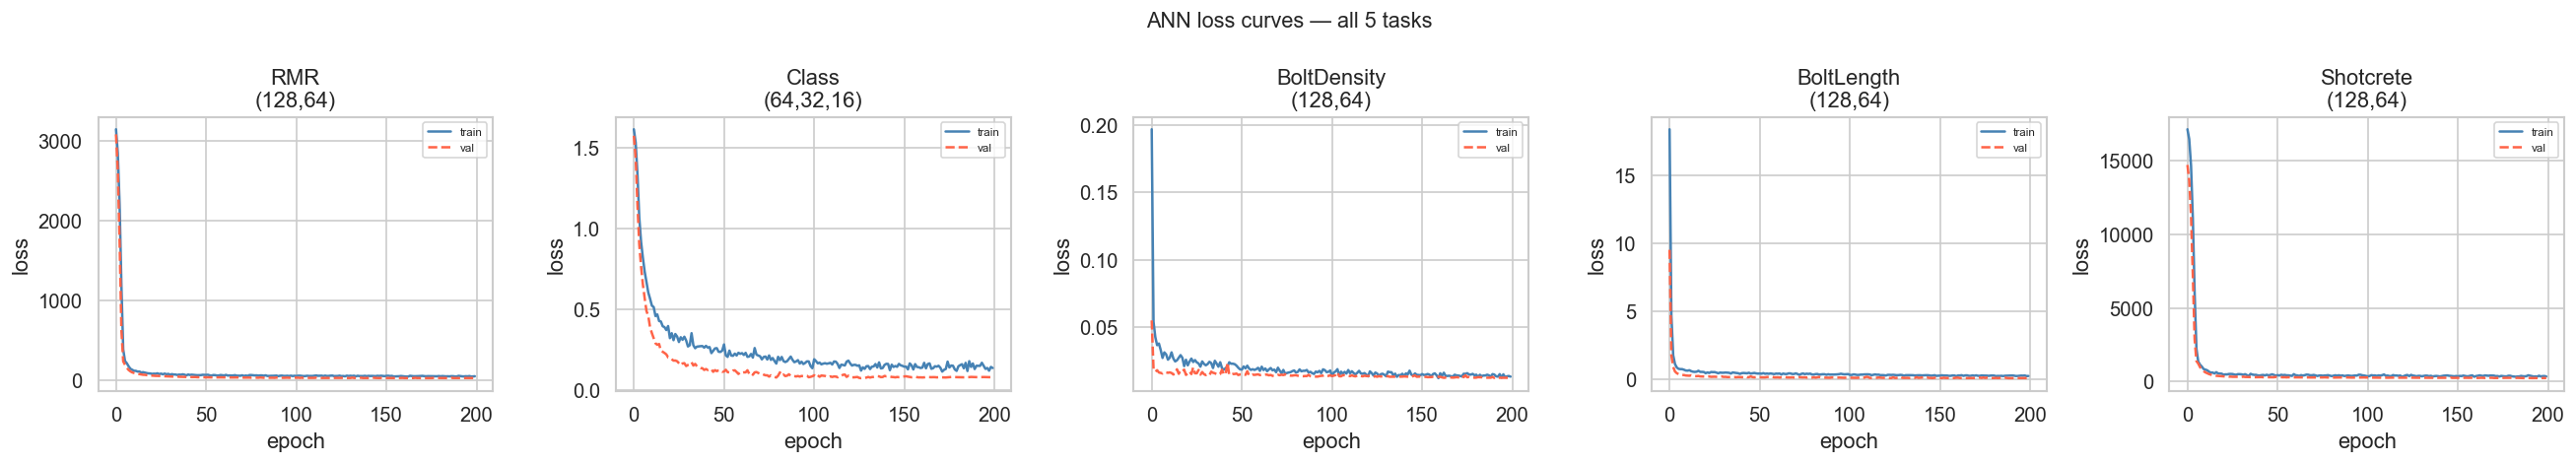

In [34]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, tn in zip(axes, ['RMR', 'Class', 'BoltDensity', 'BoltLength', 'Shotcrete']):
    tr, vl = loss_curves[tn]
    ax.plot(tr, label='train', color='steelblue', linewidth=1.5)
    ax.plot(vl, label='val', color='tomato', linewidth=1.5, linestyle='--')
    ax.set_title(f'{tn}\n({best_arch[tn].split("[")[1][:-1]})')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.legend(fontsize=7)
plt.suptitle('ANN loss curves — all 5 tasks', fontsize=13)
plt.tight_layout()
plt.savefig('fig_ann_loss.png')
plt.show()

## 10. 5-fold CV — all models

CV on TV pool (n=850). sklearn models via cross_val_score, ANN via custom pytorch k-fold.


In [35]:
cv_summary = {}

def cv_score(model, X_pool, y_pool, cv, scoring, label):
    scores = cross_val_score(model, X_pool, y_pool, cv=cv, scoring=scoring)
    cv_summary[label] = {'mean': scores.mean(), 'std': scores.std()}
    metric = 'R²' if 'r2' in scoring else 'F1'
    print(f'  {label:<38} {metric}: {scores.mean():.4f} ± {scores.std():.4f}')

print('linear :-')
cv_score(best_lr_rmr, X_tv_sc, y_rmr_tv, cv_reg, 'r2', 'Ridge/Lasso — RMR')
cv_score(lr_cls, X_tv_sc, y_cls_tv, cv_clf, 'f1_weighted', 'LogReg — class')
cv_score(best_lr_bd, X_tv_sc, y_bd_tv, cv_reg, 'r2', 'Ridge/Lasso — BoltDensity')
cv_score(best_lr_bl, X_tv_sc, y_bl_tv, cv_reg, 'r2', 'Ridge/Lasso — BoltLength')
cv_score(best_lr_sc, X_tv_sc, y_sc_tv, cv_reg, 'r2', 'Ridge/Lasso — Shotcrete')

print('\nSVM :-')
cv_score(svm_rmr, X_tv_sc, y_rmr_tv, cv_reg, 'r2', 'SVR — RMR')
cv_score(svm_cls, X_tv_sc, y_cls_tv, cv_clf, 'f1_weighted', 'SVC — class')
cv_score(svm_bd, X_tv_sc, y_bd_tv, cv_reg, 'r2', 'SVR — BoltDensity')
cv_score(svm_bl, X_tv_sc, y_bl_tv, cv_reg, 'r2', 'SVR — BoltLength')
cv_score(svm_sc, X_tv_sc, y_sc_tv, cv_reg, 'r2', 'SVR — Shotcrete')

print('\nrandom forest :-')
cv_score(rf_rmr, X_tv, y_rmr_tv, cv_reg, 'r2', 'RF — RMR')
cv_score(rf_cls, X_tv, y_cls_tv, cv_clf, 'f1_weighted', 'RF — class')
cv_score(rf_bd, X_tv, y_bd_tv, cv_reg, 'r2', 'RF — BoltDensity')
cv_score(rf_bl, X_tv, y_bl_tv, cv_reg, 'r2', 'RF — BoltLength')
cv_score(rf_sc, X_tv, y_sc_tv, cv_reg, 'r2',  'RF — Shotcrete')

print('\nsklearn CV done')

linear :-
  Ridge/Lasso — RMR                      R²: 0.9686 ± 0.0034
  LogReg — class                         F1: 0.9658 ± 0.0137
  Ridge/Lasso — BoltDensity              R²: 0.8962 ± 0.0107
  Ridge/Lasso — BoltLength               R²: 0.8969 ± 0.0182
  Ridge/Lasso — Shotcrete                R²: 0.8841 ± 0.0069

SVM :-
  SVR — RMR                              R²: 0.9756 ± 0.0046
  SVC — class                            F1: 0.9648 ± 0.0105
  SVR — BoltDensity                      R²: 0.9667 ± 0.0026
  SVR — BoltLength                       R²: 0.9593 ± 0.0065
  SVR — Shotcrete                        R²: 0.9726 ± 0.0033

random forest :-
  RF — RMR                               R²: 0.9754 ± 0.0037
  RF — class                             F1: 0.9493 ± 0.0170
  RF — BoltDensity                       R²: 0.9783 ± 0.0041
  RF — BoltLength                        R²: 0.9514 ± 0.0151
  RF — Shotcrete                         R²: 0.9592 ± 0.0136

sklearn CV done


In [38]:
def ann_kfold_cv(X_pool, y_pool, hidden_sizes, output_dim,
                 task='regression', n_splits=5,
                 epochs=200, lr=1e-3, batch_size=32, seed=SEED):
    if task == 'classification':
        kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        splits = list(kf.split(X_pool, y_pool))
    else:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        splits = list(kf.split(X_pool))

    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(splits):
        X_tr_raw, X_vl_raw = X_pool[train_idx], X_pool[val_idx]
        y_tr_raw, y_vl_raw = y_pool[train_idx], y_pool[val_idx]

        # fresh scaler per fold — no leakage
        fold_sc = StandardScaler()
        X_tr_sc = fold_sc.fit_transform(X_tr_raw).astype(np.float32)
        X_vl_sc = fold_sc.transform(X_vl_raw).astype(np.float32)

        torch.manual_seed(seed + fold_idx)
        model = RMR_ANN(X_tr_sc.shape[1], output_dim, hidden_sizes).to(device)
        criterion = nn.MSELoss() if task == 'regression' else nn.CrossEntropyLoss()

        X_tr_t = torch.tensor(X_tr_sc).to(device)
        X_vl_t = torch.tensor(X_vl_sc).to(device)
        if task == 'regression':
            y_tr_t = torch.tensor(y_tr_raw, dtype=torch.float32).unsqueeze(1).to(device)
            y_vl_t = torch.tensor(y_vl_raw, dtype=torch.float32).unsqueeze(1).to(device)
        else:
            y_tr_t = torch.tensor(y_tr_raw, dtype=torch.long).to(device)
            y_vl_t = torch.tensor(y_vl_raw, dtype=torch.long).to(device)

        loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)
        opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        sched  = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=20, factor=0.5, verbose=False)

        for epoch in range(epochs):
            model.train()
            for Xb, yb in loader:
                opt.zero_grad()
                loss = criterion(model(Xb), yb)
                loss.backward()
                opt.step()
            model.eval()
            with torch.no_grad():
                vl = criterion(model(X_vl_t), y_vl_t).item()
            sched.step(vl)

        model.eval()
        with torch.no_grad():
            out = model(X_vl_t)
            if task == 'regression':
                score = r2_score(y_vl_raw, out.squeeze(1).cpu().numpy())
            else:
                score = f1_score(y_vl_raw, torch.argmax(out, dim=1).cpu().numpy(), average='weighted')
        fold_scores.append(score)

    arr = np.array(fold_scores)
    return fold_scores, float(arr.mean()), float(arr.std())

print('ann_kfold_cv ready')

ann_kfold_cv ready


In [39]:
ann_cv_summary = {}

ann_cv_tasks = [
    ('RMR', 'regression', 1, y_rmr_tv),
    ('Class', 'classification', 5, y_cls_tv),
    ('BoltDensity', 'regression', 1, y_bd_tv),
    ('BoltLength', 'regression', 1, y_bl_tv),
    ('Shotcrete', 'regression', 1, y_sc_tv),
]

print('ANN 5-fold CV (TV pool n=850)...')
for task_name, task_type, out_dim, y_tv_pool in ann_cv_tasks:
    hidden = ARCH_CONFIGS[best_arch[task_name]]
    print(f'  [{task_name}] arch={best_arch[task_name][:20]}')
    fold_scores, mean_score, std_score = ann_kfold_cv(
        X_tv, y_tv_pool, hidden, out_dim, task=task_type
    )
    metric = 'R²' if task_type == 'regression' else 'F1'
    ann_cv_summary[f'ANN — {task_name}'] = {'mean': mean_score, 'std': std_score}
    print(f'folds: {[round(s,4) for s in fold_scores]}')
    print(f'mean ± std: {mean_score:.4f} ± {std_score:.4f}')

print('\nANN CV done')

ANN 5-fold CV (TV pool n=850)...
  [RMR] arch=C_wider [128,64]
folds: [0.976, 0.9738, 0.973, 0.9791, 0.9758]
mean ± std: 0.9755 ± 0.0021
  [Class] arch=D_deeper [64,32,16]
folds: [0.9649, 0.9647, 0.9585, 0.9179, 0.9355]
mean ± std: 0.9483 ± 0.0186
  [BoltDensity] arch=C_wider [128,64]
folds: [0.9688, 0.9652, 0.9678, 0.9697, 0.9745]
mean ± std: 0.9692 ± 0.0031
  [BoltLength] arch=C_wider [128,64]
folds: [0.9599, 0.956, 0.9651, 0.9633, 0.9378]
mean ± std: 0.9564 ± 0.0098
  [Shotcrete] arch=C_wider [128,64]
folds: [0.9707, 0.9674, 0.971, 0.9733, 0.9579]
mean ± std: 0.9681 ± 0.0054

ANN CV done


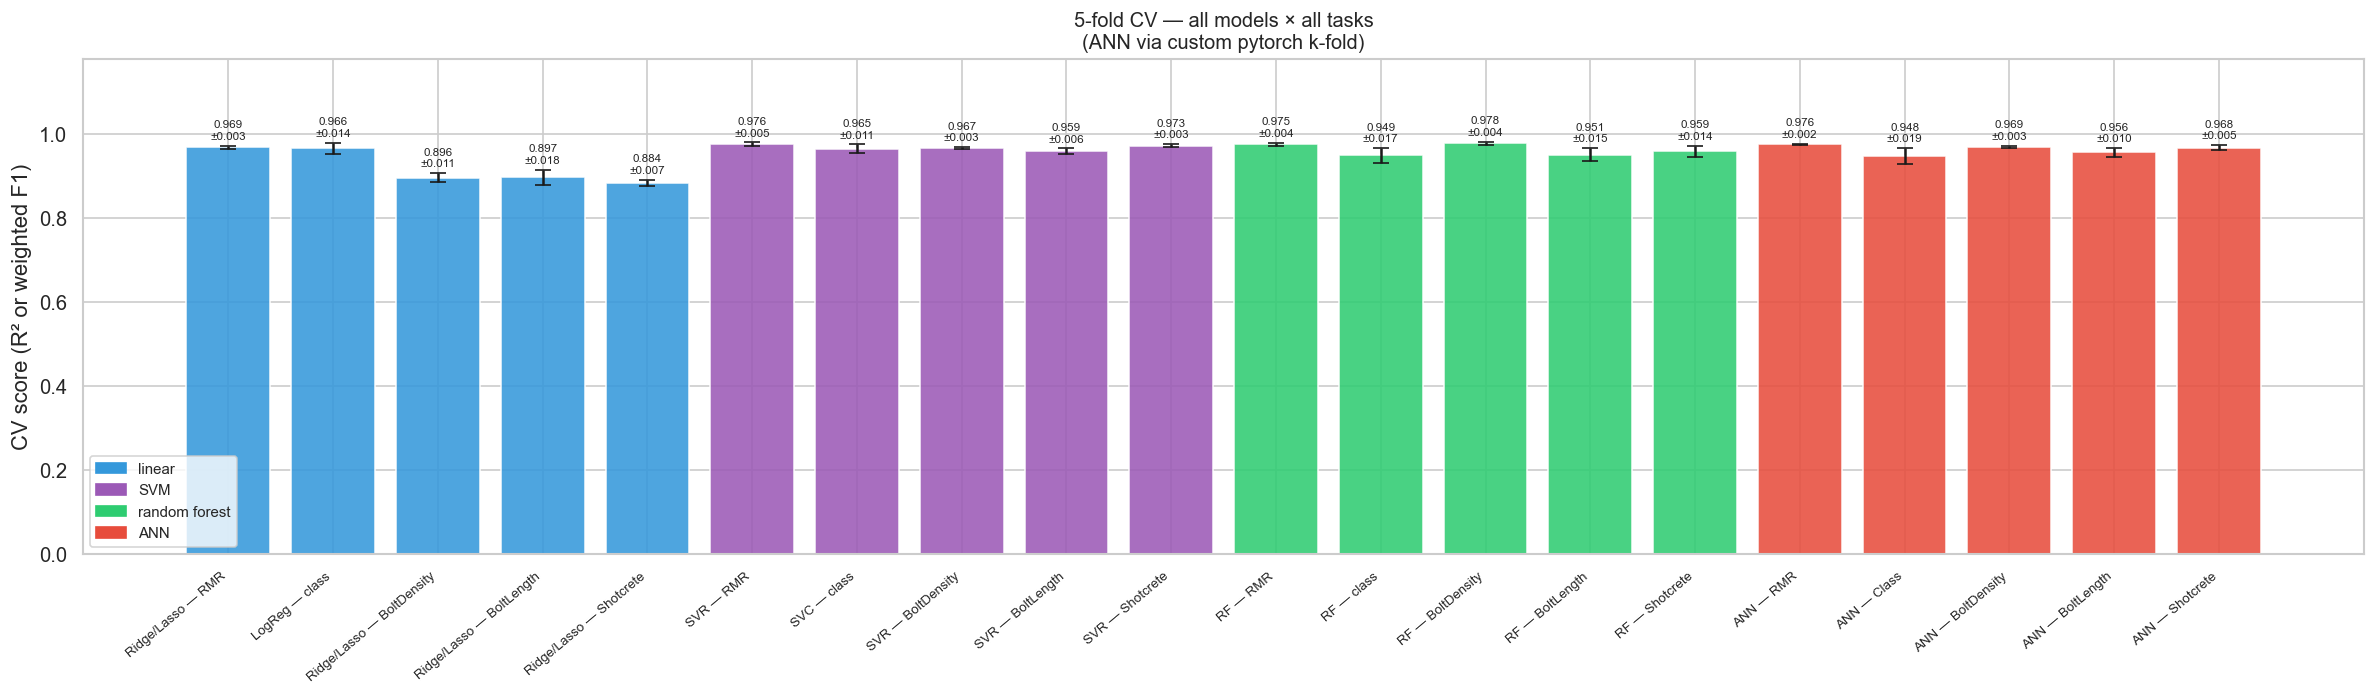

In [41]:
all_cv = {**cv_summary, **ann_cv_summary}

labels = list(all_cv.keys())
means = [all_cv[k]['mean'] for k in labels]
stds = [all_cv[k]['std']  for k in labels]

def bar_color(lbl):
    if 'Ridge' in lbl or 'Lasso' in lbl or 'LogReg' in lbl: return '#3498db'
    if 'SVR' in lbl or 'SVC' in lbl: return '#9b59b6'
    if 'RF' in lbl: return '#2ecc71'
    return '#e74c3c'

colors = [bar_color(l) for l in labels]

fig, ax = plt.subplots(figsize=(20, 6))
bars = ax.bar(range(len(labels)), means, yerr=stds,
              color=colors, edgecolor='white', capsize=5, alpha=0.87)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('CV score (R² or weighted F1)')
ax.set_title('5-fold CV — all models × all tasks\n(ANN via custom pytorch k-fold)', fontsize=12)
ax.set_ylim(0, 1.18)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.015,
            f'{m:.3f}\n±{s:.3f}', ha='center', fontsize=7)
ax.legend(handles=[
    mpatches.Patch(color='#3498db', label='linear'),
    mpatches.Patch(color='#9b59b6', label='SVM'),
    mpatches.Patch(color='#2ecc71', label='random forest'),
    mpatches.Patch(color='#e74c3c', label='ANN'),
], fontsize=9)
plt.tight_layout()
plt.savefig('fig_cv_all_models.png')
plt.show()

## 11. confusion matrices


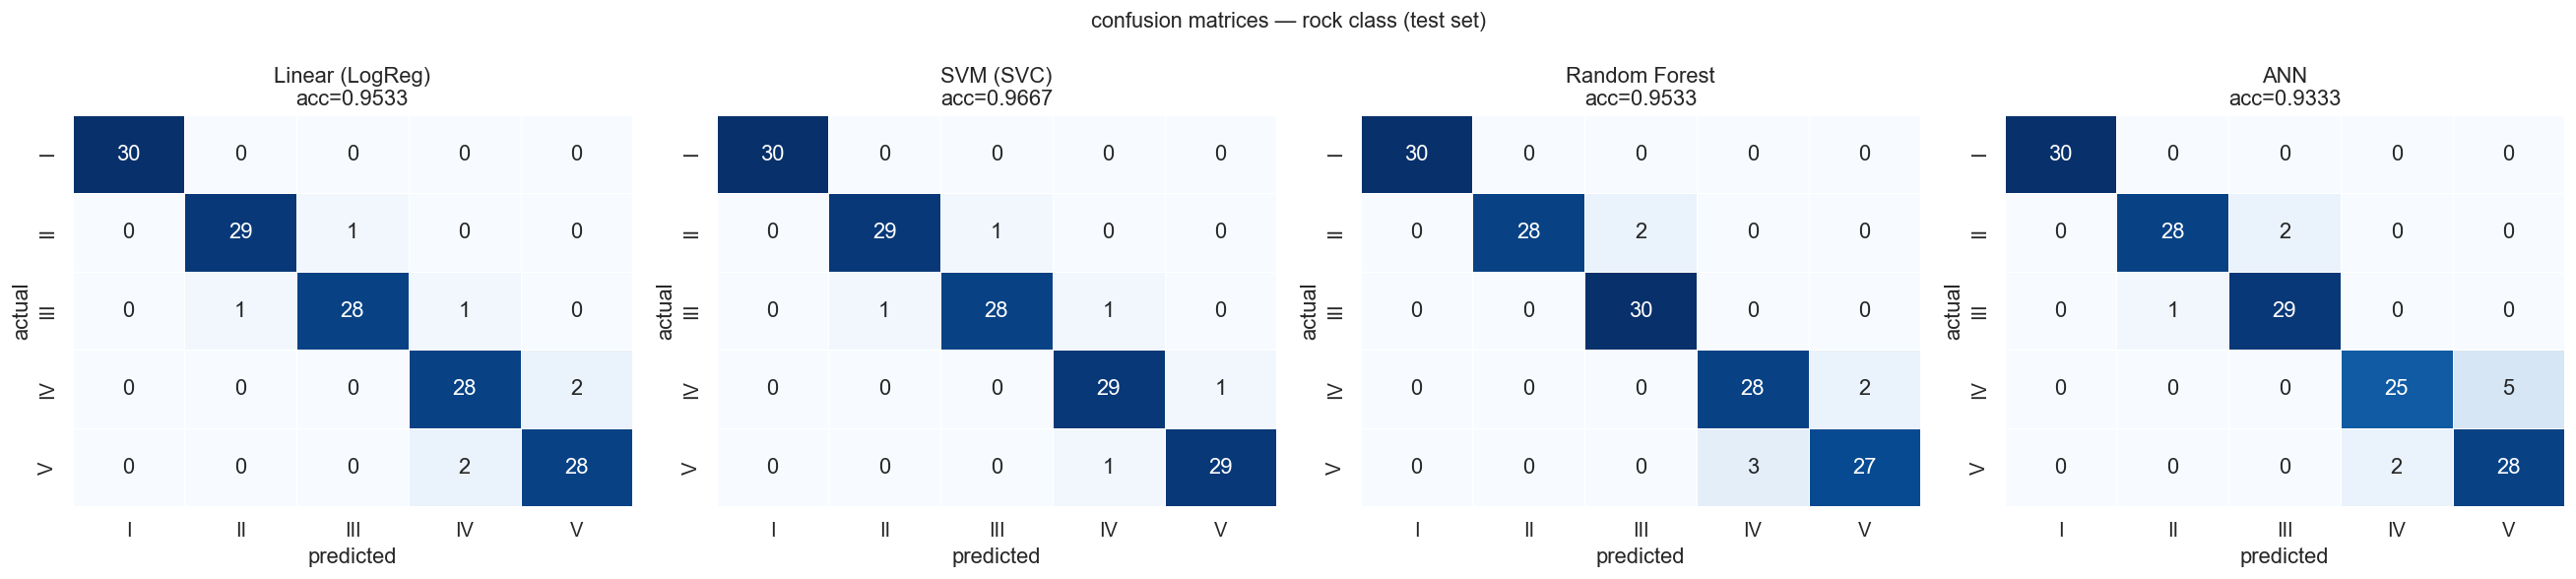

In [42]:
cls_preds = [
    ('Linear (LogReg)', lr_cls_pred_test),
    ('SVM (SVC)', svm_cls_pred_test),
    ('Random Forest', rf_cls_pred_test),
    ('ANN', ann_cls_pred_test),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, preds) in zip(axes, cls_preds):
    cm = confusion_matrix(y_cls_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
                linewidths=0.5, linecolor='white', cbar=False)
    acc = accuracy_score(y_cls_test, preds)
    ax.set_title(f'{name}\nacc={acc:.4f}')
    ax.set_xlabel('predicted')
    ax.set_ylabel('actual')

plt.suptitle('confusion matrices — rock class (test set)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png')
plt.show()

In [ ]:
# hardest boundaries are II/III and III/IV — narrow RMR bands, noise pushes samples across
# class I and V cleanest — extreme classes easier to separate
# RF has fewest off-diagonal errors overall
# ANN occasionally calls class II as class I — same issue as shotcrete underestimation


In [44]:
for name, preds in cls_preds:
    print(f'\n {name} :-')
    print(classification_report(y_cls_test, preds,
                                target_names=[f'Class {c}' for c in CLASS_ORDER]))


 Linear (LogReg) :-
              precision    recall  f1-score   support

     Class I       1.00      1.00      1.00        30
    Class II       0.97      0.97      0.97        30
   Class III       0.97      0.93      0.95        30
    Class IV       0.90      0.93      0.92        30
     Class V       0.93      0.93      0.93        30

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150


 SVM (SVC) :-
              precision    recall  f1-score   support

     Class I       1.00      1.00      1.00        30
    Class II       0.97      0.97      0.97        30
   Class III       0.97      0.93      0.95        30
    Class IV       0.94      0.97      0.95        30
     Class V       0.97      0.97      0.97        30

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.

## 12. actual vs predicted — regression


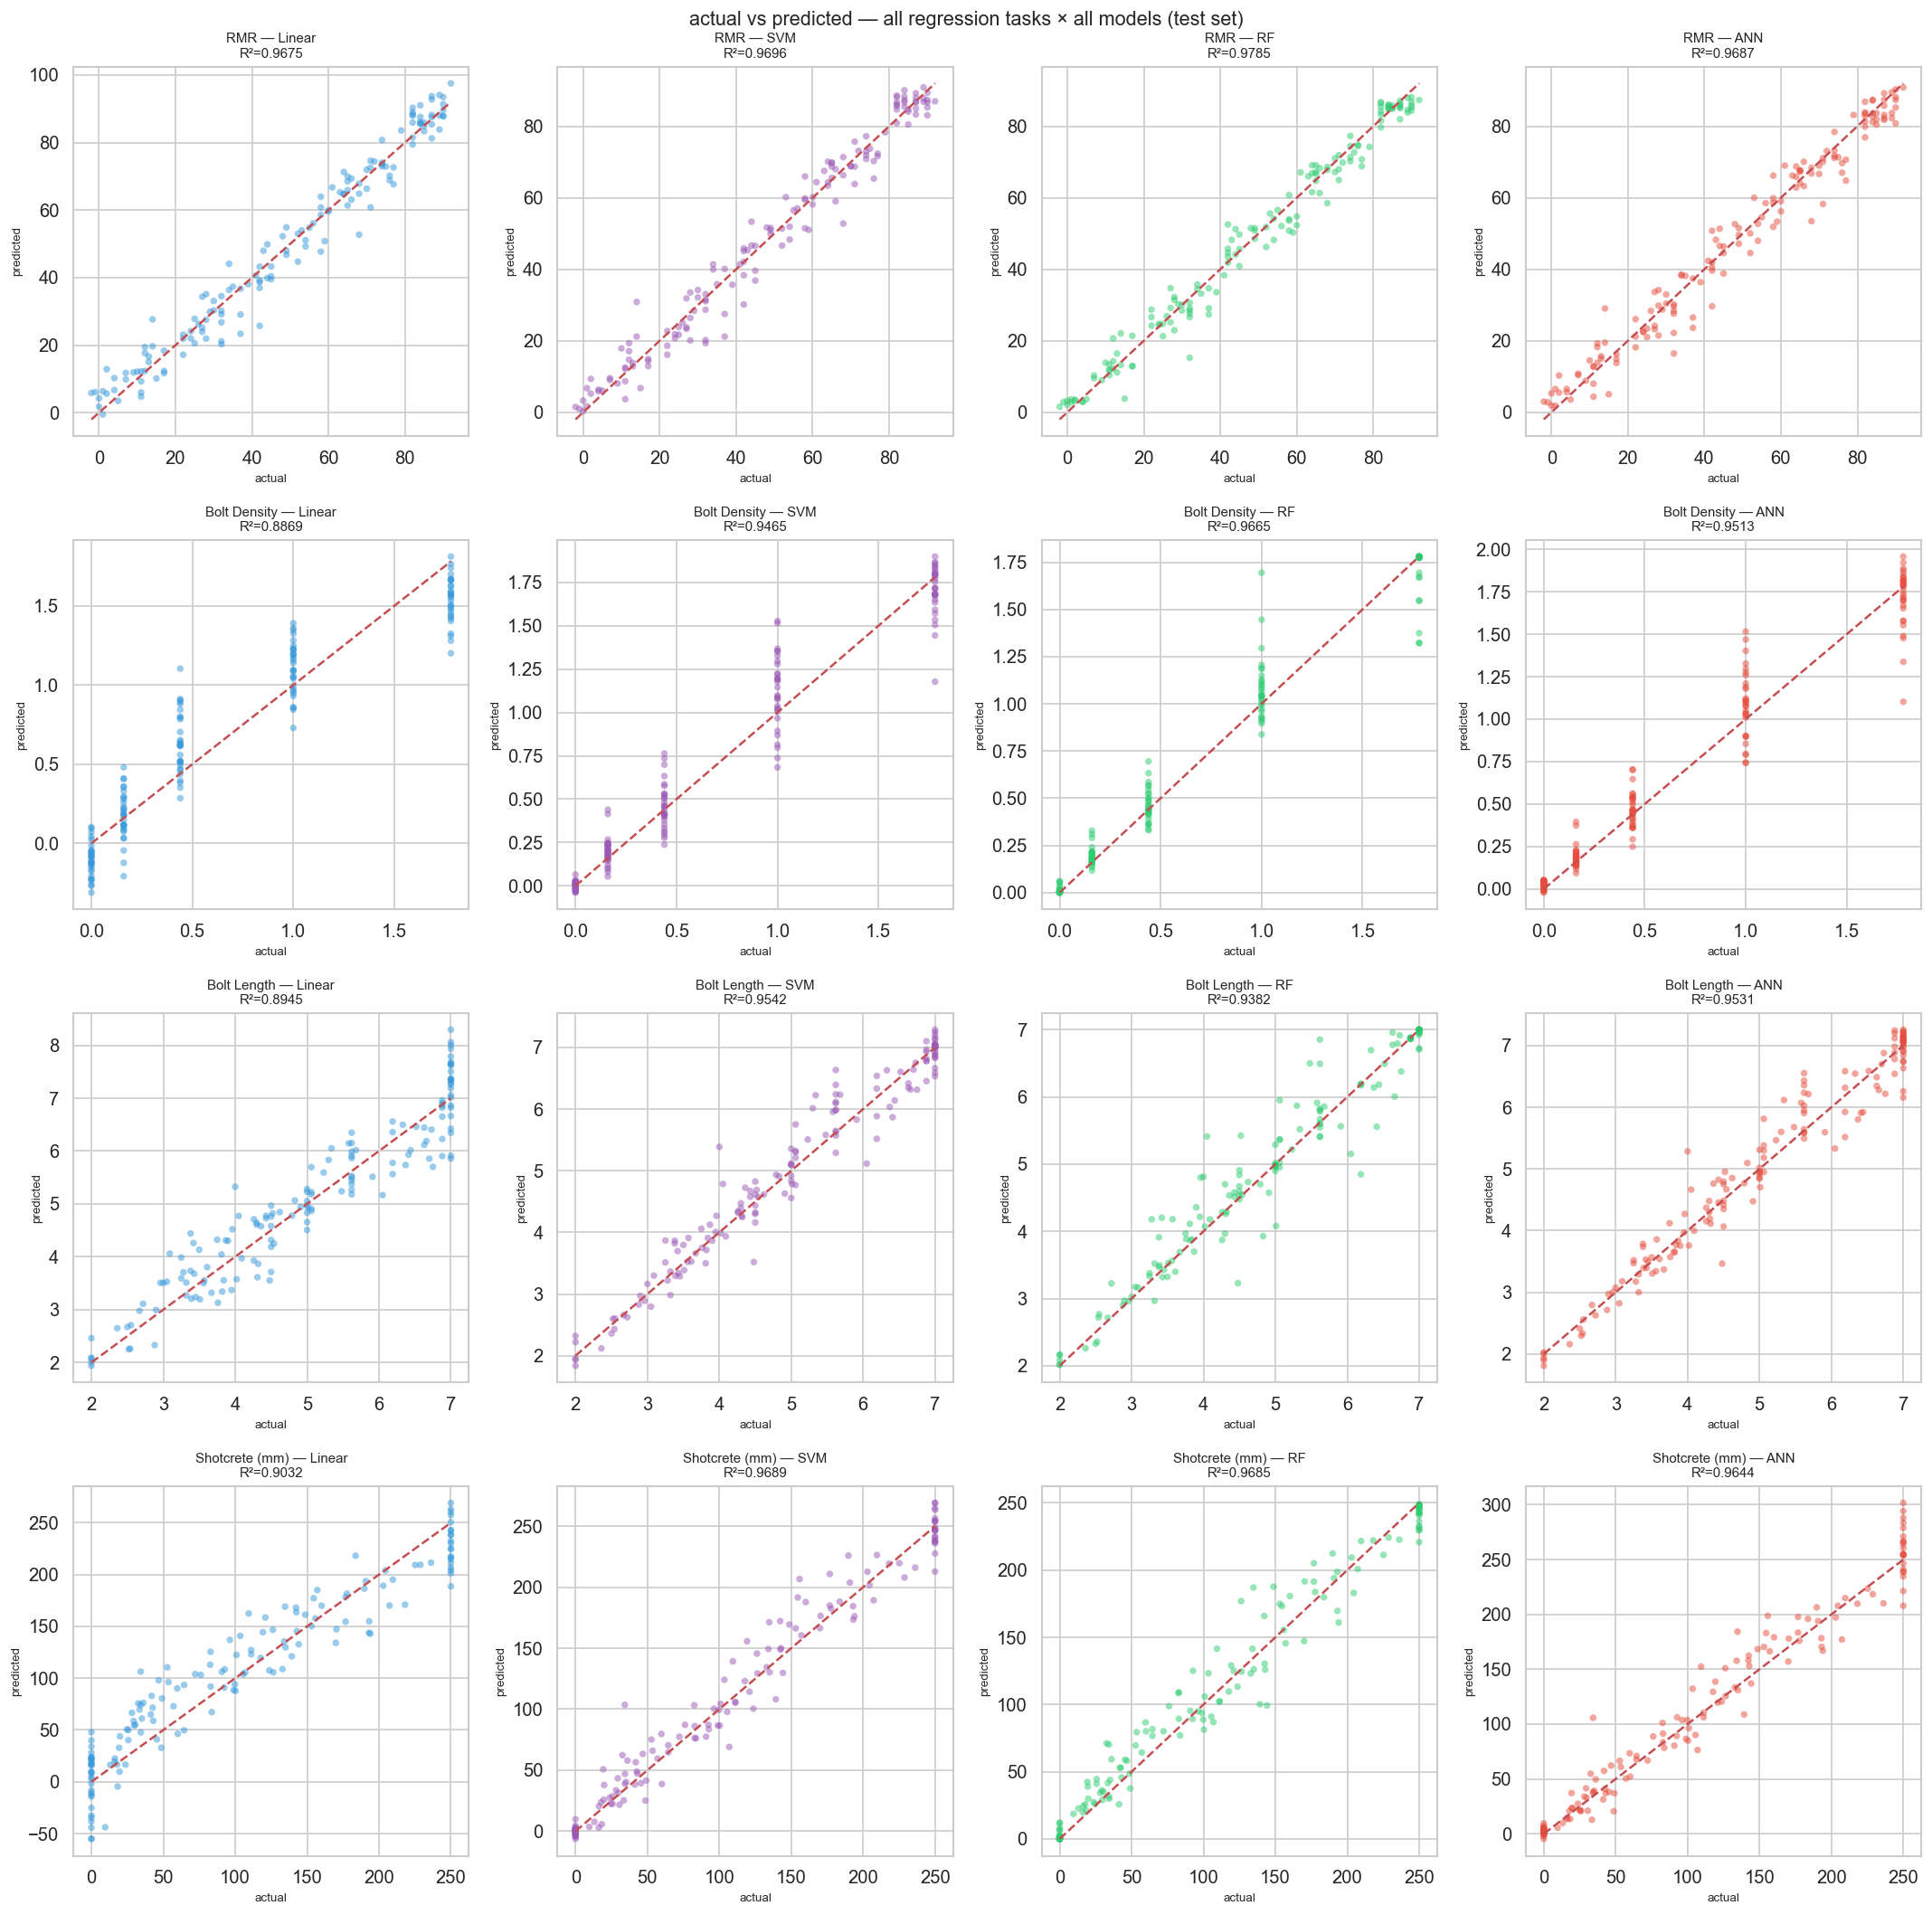

In [45]:
reg_task_preds = [
    ('RMR', y_rmr_test, lr_rmr_pred_test, svm_rmr_pred_test, rf_rmr.predict(X_test), ann_rmr_pred_test),
    ('Bolt Density', y_bd_test, lr_bd_pred_test, svm_bd_pred_test, rf_bd.predict(X_test), ann_bd_pred_test),
    ('Bolt Length', y_bl_test, lr_bl_pred_test, svm_bl_pred_test, rf_bl.predict(X_test), ann_bl_pred_test),
    ('Shotcrete (mm)', y_sc_test, lr_sc_pred_test, svm_sc_pred_test, rf_sc.predict(X_test), ann_sc_pred_test),
]

model_names_reg = ['Linear', 'SVM', 'RF', 'ANN']
model_colors = ['#3498db', '#9b59b6', '#2ecc71', '#e74c3c']

fig, axes = plt.subplots(4, 4, figsize=(18, 18))
for row, (task_name, y_true, lr_p, svm_p, rf_p, ann_p) in enumerate(reg_task_preds):
    for col, (mname, preds, color) in enumerate(
        zip(model_names_reg, [lr_p, svm_p, rf_p, ann_p], model_colors)):
        ax = axes[row, col]
        ax.scatter(y_true, preds, alpha=0.5, s=20, color=color, edgecolors='none')
        lo, hi = y_true.min(), y_true.max()
        ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)
        r2 = r2_score(y_true, preds)
        ax.set_title(f'{task_name} — {mname}\nR²={r2:.4f}', fontsize=9)
        ax.set_xlabel('actual', fontsize=8)
        ax.set_ylabel('predicted', fontsize=8)

plt.suptitle('actual vs predicted — all regression tasks × all models (test set)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_actual_vs_predicted.png')
plt.show()

## 13. results table


In [47]:
model_names = list(results.keys())
rows = []
for m in model_names:
    r = results[m]
    rows.append({
        'model': m,
        'RMR_R2': round(r['RMR_test']['R2'], 4),
        'RMR_RMSE': round(r['RMR_test']['RMSE'], 4),
        'cls_acc': round(r['Class_test']['Accuracy'], 4),
        'cls_f1': round(r['Class_test']['F1_weighted'], 4),
        'BD_R2': round(r['BD_test']['R2'], 4),
        'BL_R2': round(r['BL_test']['R2'], 4),
        'BL_RMSE': round(r['BL_test']['RMSE'], 4),
        'SC_R2': round(r['SC_test']['R2'], 4),
        'SC_RMSE': round(r['SC_test']['RMSE'], 4),
    })

comparison_df = pd.DataFrame(rows).set_index('model')
comparison_df.to_csv('model_comparison.csv')
print('saved model_comparison.csv')
comparison_df

saved model_comparison.csv


,RMR_R2,RMR_RMSE,cls_acc,cls_f1,BD_R2,BL_R2,BL_RMSE,SC_R2,SC_RMSE
model,,,,,,,,,
Linear Regression,0.9675,5.0785,0.9533,0.9534,0.8869,0.8945,0.4924,0.9032,27.4572
SVM,0.9696,4.9109,0.9667,0.9667,0.9465,0.9542,0.3243,0.9689,15.5600
Random Forest,0.9785,4.1282,0.9533,0.9533,0.9665,0.9382,0.3768,0.9685,15.6586
ANN,0.9687,4.9847,0.9333,0.9332,0.9513,0.9531,0.3282,0.9644,16.6544


## 14. comparison plots


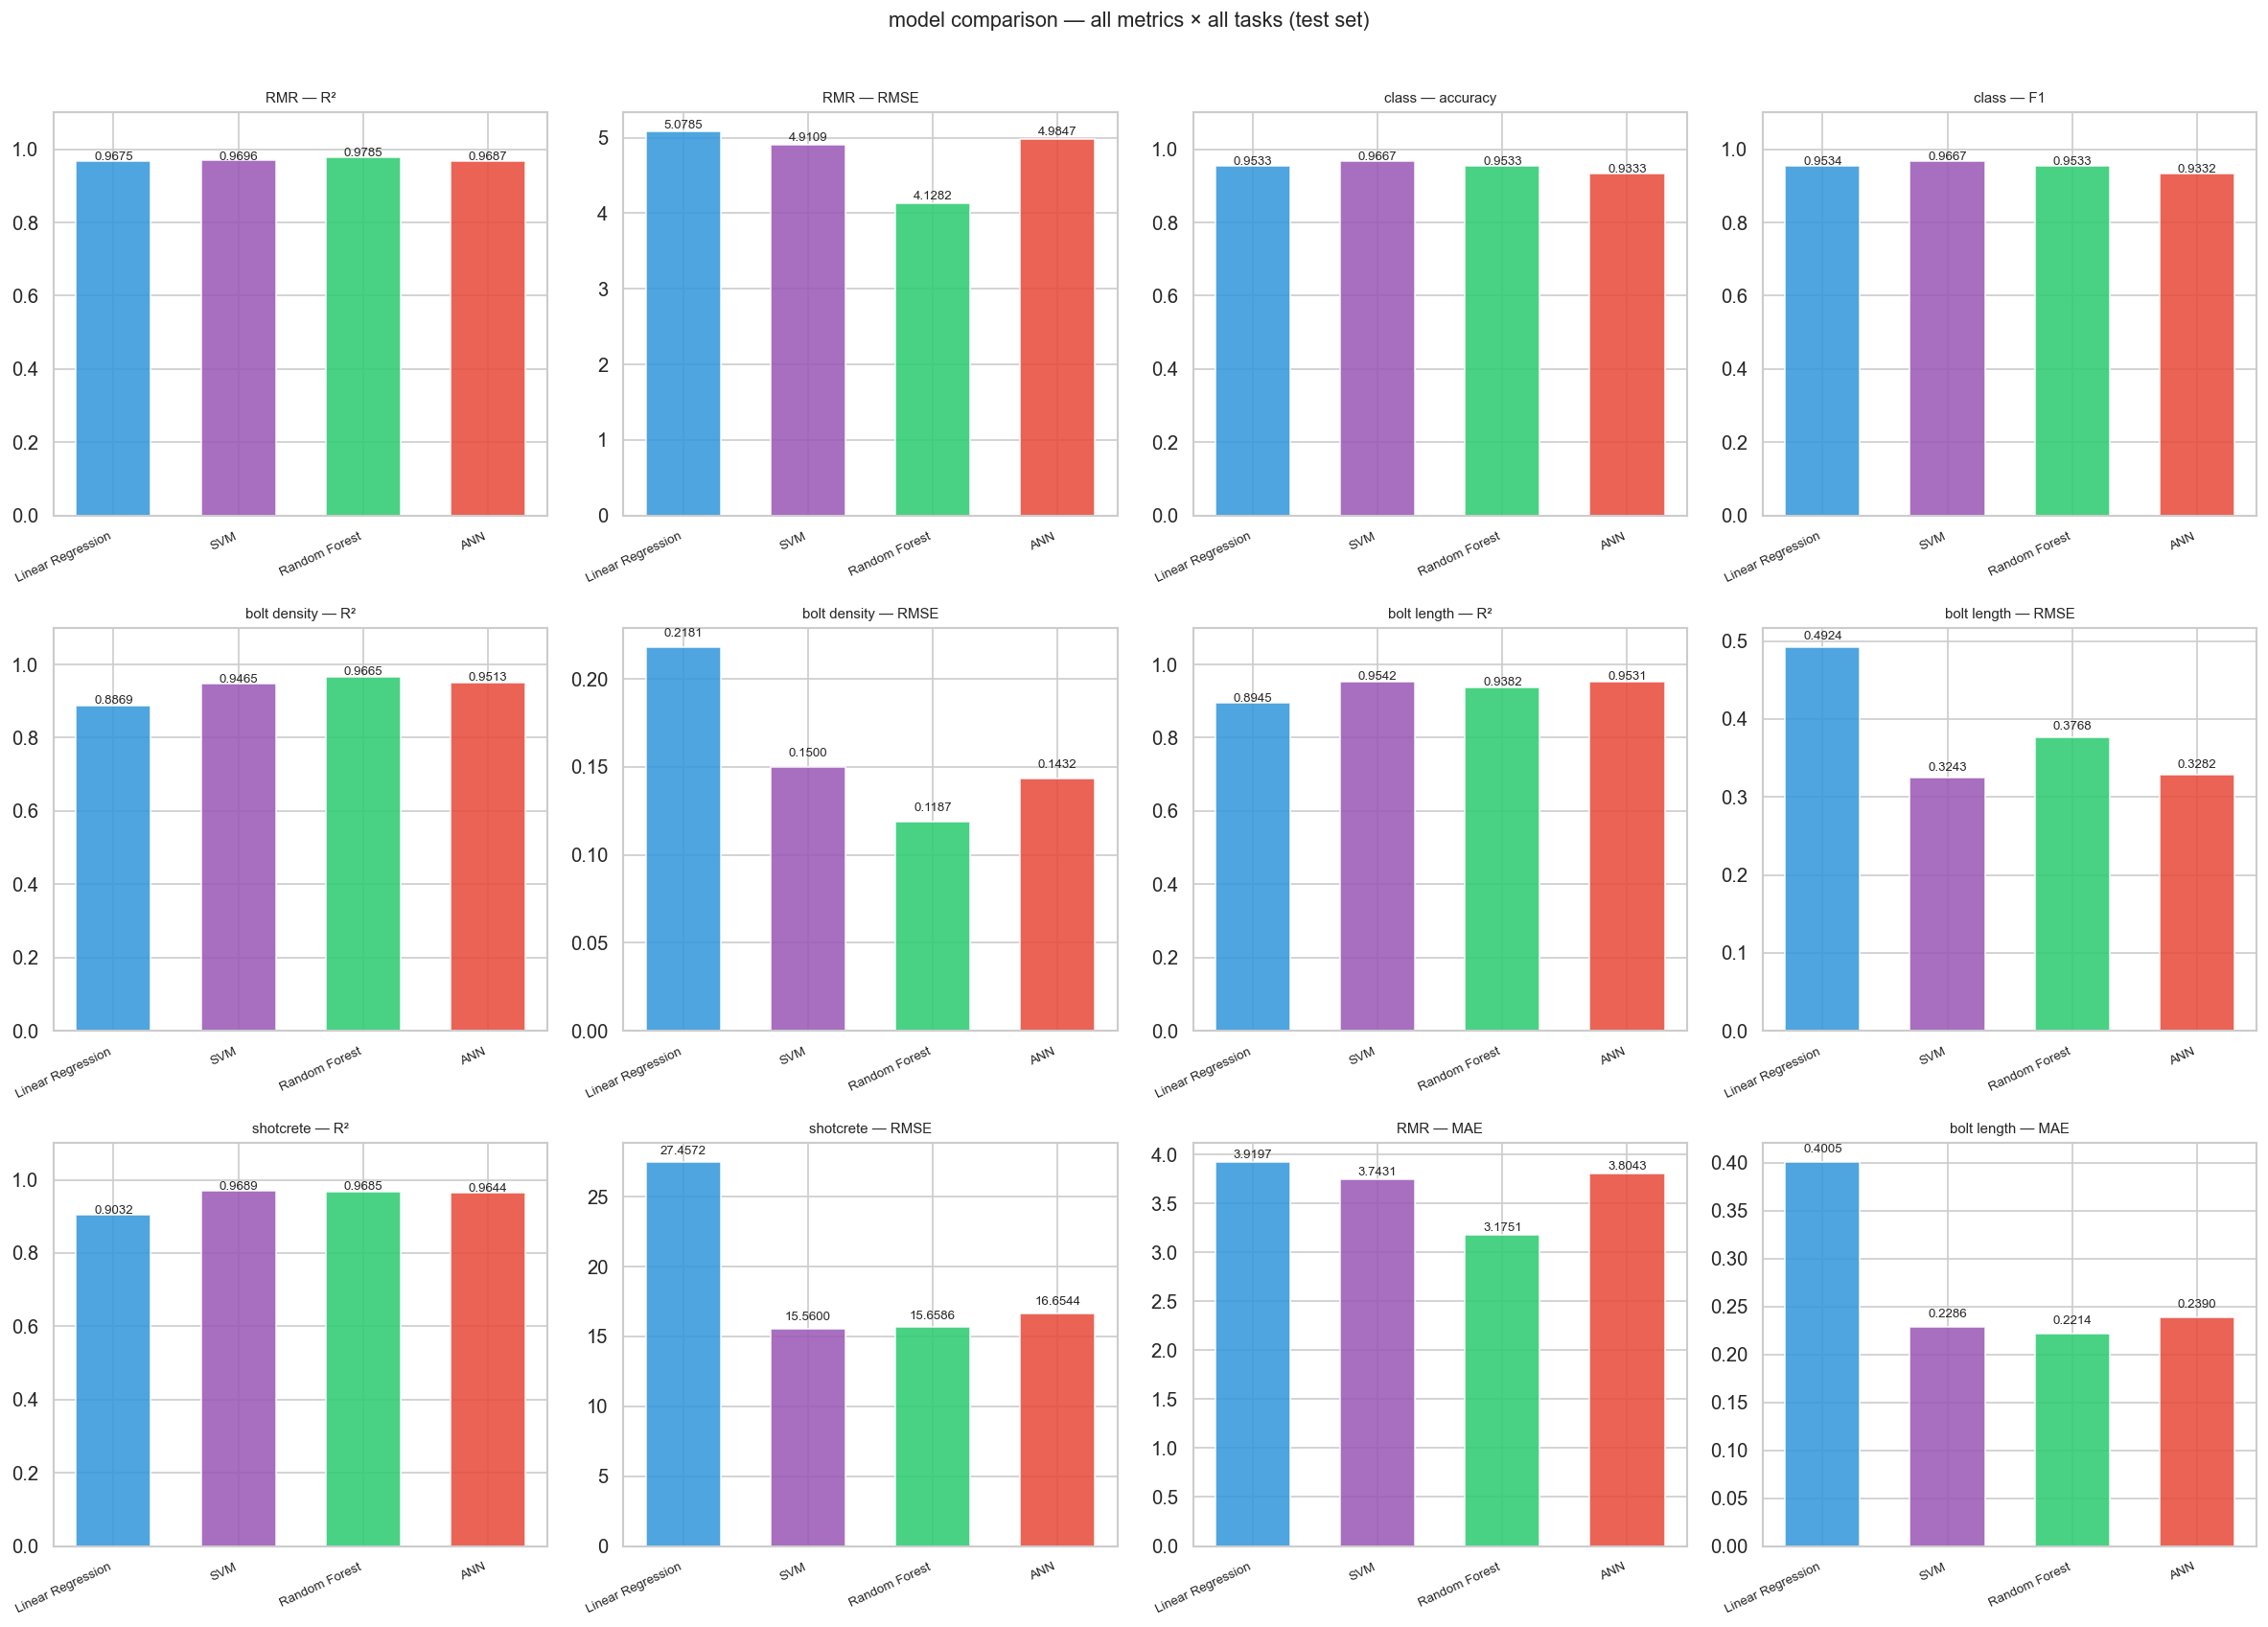

In [48]:
bar_colors = ['#3498db', '#9b59b6', '#2ecc71', '#e74c3c']
w = 0.6

metrics_to_plot = [
    ('RMR_test', 'R2', 'RMR — R²', (0.0, 1.1)),
    ('RMR_test', 'RMSE', 'RMR — RMSE', None),
    ('Class_test', 'Accuracy', 'class — accuracy', (0.0, 1.1)),
    ('Class_test', 'F1_weighted', 'class — F1', (0.0, 1.1)),
    ('BD_test', 'R2', 'bolt density — R²', (0.0, 1.1)),
    ('BD_test', 'RMSE', 'bolt density — RMSE',None),
    ('BL_test', 'R2', 'bolt length — R²',   (0.0, 1.1)),
    ('BL_test', 'RMSE', 'bolt length — RMSE', None),
    ('SC_test', 'R2', 'shotcrete — R²', (0.0, 1.1)),
    ('SC_test', 'RMSE', 'shotcrete — RMSE', None),
    ('RMR_test', 'MAE', 'RMR — MAE', None),
    ('BL_test', 'MAE', 'bolt length — MAE', None),
]

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
for ax, (key, sub, title, ylim) in zip(axes.flat, metrics_to_plot):
    vals = [results[m][key][sub] for m in model_names]
    ax.bar(model_names, vals, color=bar_colors, width=w, edgecolor='white', alpha=0.87)
    ax.set_title(title, fontsize=9)
    ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=8)
    if ylim:
        ax.set_ylim(*ylim)
    pad = (max(vals) - min(vals)) * 0.05 + 0.001
    for i, v in enumerate(vals):
        ax.text(i, v + pad, f'{v:.4f}', ha='center', fontsize=8)

plt.suptitle('model comparison — all metrics × all tasks (test set)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_model_comparison.png')
plt.show()

## 15. save models


In [52]:
import joblib

# sklearn models
joblib.dump(best_lr_rmr, 'model_lr_rmr.pkl')
joblib.dump(lr_cls, 'model_lr_class.pkl')
joblib.dump(best_lr_bd, 'model_lr_bolt_density.pkl')
joblib.dump(best_lr_bl, 'model_lr_bolt_length.pkl')
joblib.dump(best_lr_sc, 'model_lr_shotcrete.pkl')

joblib.dump(svm_rmr, 'model_svm_rmr.pkl')
joblib.dump(svm_cls, 'model_svm_class.pkl')
joblib.dump(svm_bd, 'model_svm_bolt_density.pkl')
joblib.dump(svm_bl, 'model_svm_bolt_length.pkl')
joblib.dump(svm_sc, 'model_svm_shotcrete.pkl')

joblib.dump(rf_rmr, 'model_rf_rmr.pkl')
joblib.dump(rf_cls, 'model_rf_class.pkl')
joblib.dump(rf_bd, 'model_rf_bolt_density.pkl')
joblib.dump(rf_bl, 'model_rf_bolt_length.pkl')
joblib.dump(rf_sc, 'model_rf_shotcrete.pkl')

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

# gridsearch objects — useful for checking cv_results_ later
joblib.dump(gs_svm_rmr, 'gs_svm_rmr.pkl')
joblib.dump(gs_svc, 'gs_svc.pkl')
joblib.dump(gs_rf_rmr, 'gs_rf_rmr.pkl')
joblib.dump(gs_rf_cls, 'gs_rf_cls.pkl')
joblib.dump(gs_log, 'gs_logistic.pkl')

# ANN weights + arch info
for task_name, model in final_ann.items():
    torch.save(model.state_dict(), f'model_ann_{task_name.lower()}.pth')

with open('ann_architectures.json', 'w') as f:
    json.dump({task: ARCH_CONFIGS[arch] for task, arch in best_arch.items()}, f, indent=2)

print('saved:')
print(' model_lr_*.pkl  model_svm_*.pkl  model_rf_*.pkl')
print(' model_ann_*.pth  scaler.pkl  label_encoder.pkl')
print(' gs_*.pkl  ann_architectures.json')

saved:
 model_lr_*.pkl  model_svm_*.pkl  model_rf_*.pkl
 model_ann_*.pth  scaler.pkl  label_encoder.pkl
 gs_*.pkl  ann_architectures.json


## 16. summary


In [56]:
for task_key, task_label, metric_key in [
    ('RMR_test', 'RMR regression', 'R2'),
    ('Class_test', 'rock class classification','Accuracy'),
    ('BD_test', 'bolt density regression', 'R2'),
    ('BL_test', 'bolt length regression', 'R2'),
    ('SC_test', 'shotcrete regression',  'R2'),
]:
    print(f'\n{task_label}:')
    print(f' {"model":<20} {metric_key:>8} {"RMSE/F1":>10}')
    print('  ' )
    for m in model_names:
        val  = results[m][task_key][metric_key]
        val2 = results[m][task_key].get('RMSE', results[m][task_key].get('F1_weighted', float('nan')))
        print(f'  {m:<20} {val:>8.4f} {val2:>10.4f}')

print('\nhyperparams:')
print(f' ridge alpha (RMR): {ridge_rmr.alpha_:.4f}')
print(f' lasso alpha (RMR): {lasso_rmr.alpha_:.4f}')
print(f' best logreg(RMR): {gs_log.best_params_}')
print(f' best SVR (RMR): {gs_svm_rmr.best_params_}')
print(f' best SVC: {gs_svc.best_params_}')
print(f' best RF (RMR): {gs_rf_rmr.best_params_}')

print('\nbest ANN archs:')
for task, arch in best_arch.items():
    print(f'  {task}: {arch}')

print('\nCV highlights:')
for k in ['RF — RMR', 'ANN — RMR', 'RF — BoltLength', 'ANN — BoltLength',
          'RF — Shotcrete', 'ANN — Shotcrete']:
    if k in all_cv:
        print(f'  {k:<30}: {all_cv[k]["mean"]:.4f} ± {all_cv[k]["std"]:.4f}')

print('\nfigs: fig_*.png   models: model_*.pkl / model_*.pth')


RMR regression:
 model                      R2    RMSE/F1
  
  Linear Regression      0.9675     5.0785
  SVM                    0.9696     4.9109
  Random Forest          0.9785     4.1282
  ANN                    0.9687     4.9847

rock class classification:
 model                Accuracy    RMSE/F1
  
  Linear Regression      0.9533     0.9534
  SVM                    0.9667     0.9667
  Random Forest          0.9533     0.9533
  ANN                    0.9333     0.9332

bolt density regression:
 model                      R2    RMSE/F1
  
  Linear Regression      0.8869     0.2181
  SVM                    0.9465     0.1500
  Random Forest          0.9665     0.1187
  ANN                    0.9513     0.1432

bolt length regression:
 model                      R2    RMSE/F1
  
  Linear Regression      0.8945     0.4924
  SVM                    0.9542     0.3243
  Random Forest          0.9382     0.3768
  ANN                    0.9531     0.3282

shotcrete regression:
 model       